In [1]:
import numpy as np
from healpix_plot.mollview import mollview

t_map = np.random.randn(12*64**2)

In [2]:
%load_ext autoreload
%autoreload 2

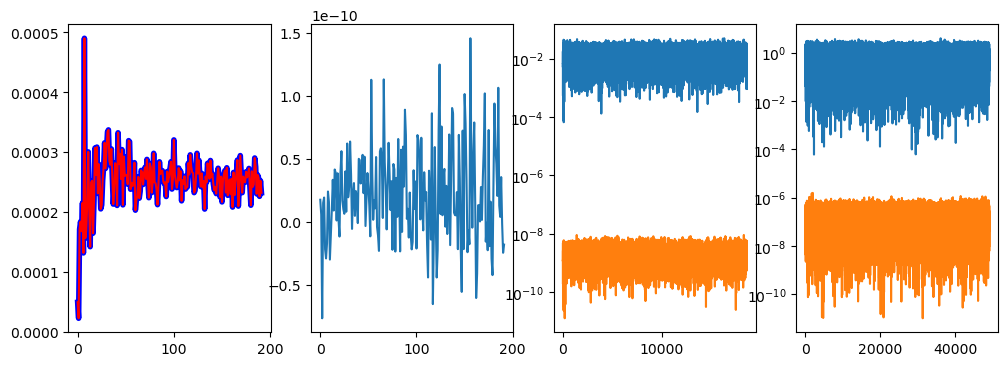

In [3]:
from healpix_analyse.healpix_sht import HEALPixSHT
import healpy as hp
import matplotlib.pyplot as plt

sht = HEALPixSHT(nside=64)          # ~0.5 s de précomputation

# Spin-0 (scalaire)
alm  = sht.map2alm(t_map)           # différentiable
alm_hp = hp.map2alm(t_map,iter=0)
t_rec = sht.alm2map(alm)
t_rec_hp = hp.alm2map(alm_hp,nside=64)
cl   = sht.anafast(t_map)
cl_hp = hp.anafast(t_map,iter=0)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.plot(cl_hp,color='b',lw=4)
plt.plot(cl.cpu().numpy(),color='r')
plt.subplot(1,4,2)
plt.plot(cl_hp-cl.cpu().numpy())
plt.subplot(1,4,3)
plt.plot(abs(alm_hp))
plt.plot(abs(alm_hp-alm.cpu().numpy()))
plt.yscale('log')
plt.subplot(1,4,4)
plt.plot(abs(t_rec_hp))
plt.plot(abs(t_rec_hp-t_rec.cpu().numpy()))
plt.yscale('log')

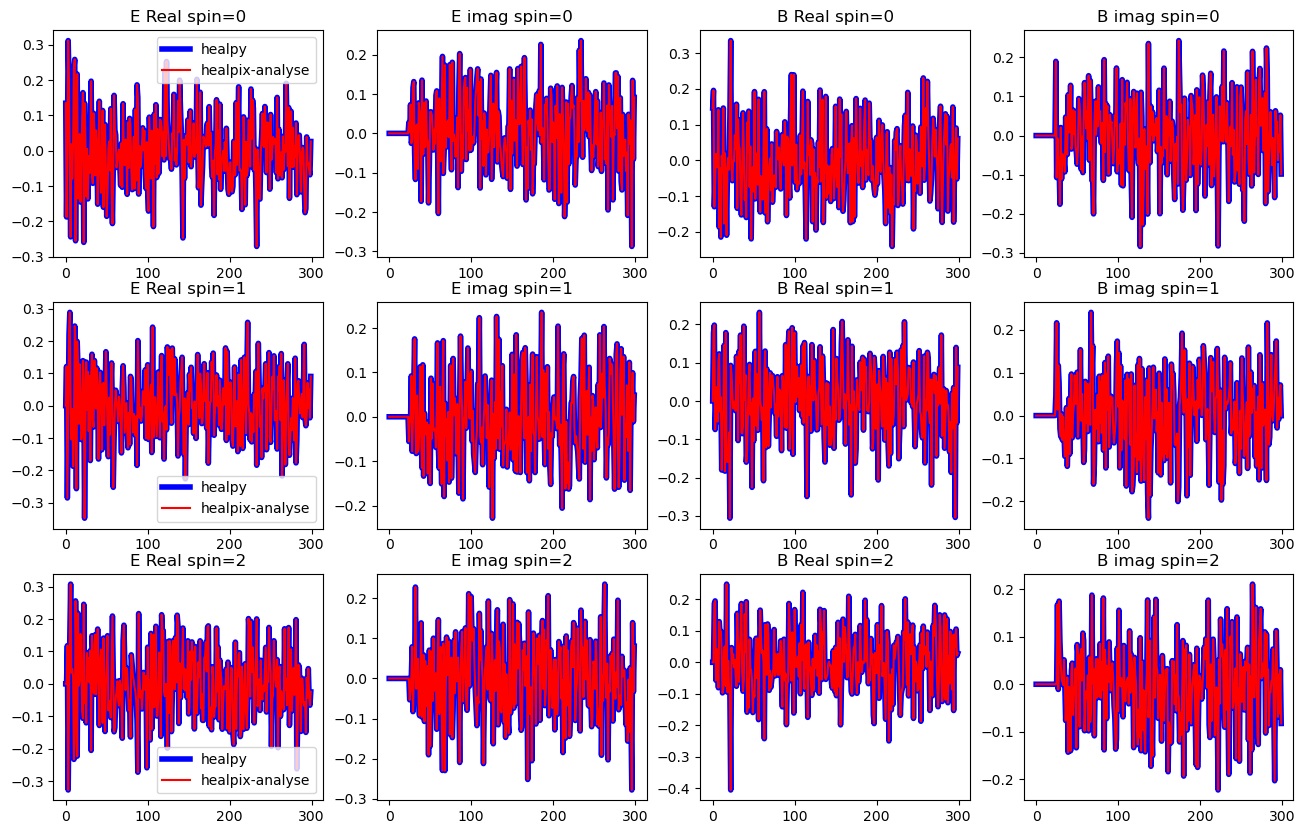

In [4]:
import torch

nside=8
sht = HEALPixSHT(nside=nside)          # ~0.5 s de précomputation
Q=np.random.randn(12*nside**2)
U=np.random.randn(12*nside**2)

plt.figure(figsize=(16,10))
for spin in range(3):
    # Spin-2 (Q/U → E/B) — pour l'apprentissage
    almE, almB = sht.map2alm_spin(Q,U, spin=spin)
    almE_hp, almB_hp = hp.map2alm_spin(np.vstack([Q,U]),spin)
    
    plt.subplot(3,4,1+4*spin)
    plt.title('E Real spin=%d'%(spin))
    plt.plot(almE_hp.real,color='b',lw=4,label='healpy')
    plt.plot(almE.cpu().numpy().real,color='r',label='healpix-analyse')
    plt.legend()
    plt.subplot(3,4,2+4*spin)
    plt.title('E imag spin=%d'%(spin))
    plt.plot(almE_hp.imag,color='b',lw=4)
    plt.plot(almE.cpu().numpy().imag,color='r')
    plt.subplot(3,4,3+4*spin)
    plt.title('B Real spin=%d'%(spin))
    plt.plot(almB_hp.real,color='b',lw=4)
    plt.plot(almB.cpu().numpy().real,color='r')
    plt.subplot(3,4,4+4*spin)
    plt.title('B imag spin=%d'%(spin))
    plt.plot(almB_hp.imag,color='b',lw=4)
    plt.plot(almB.cpu().numpy().imag,color='r')

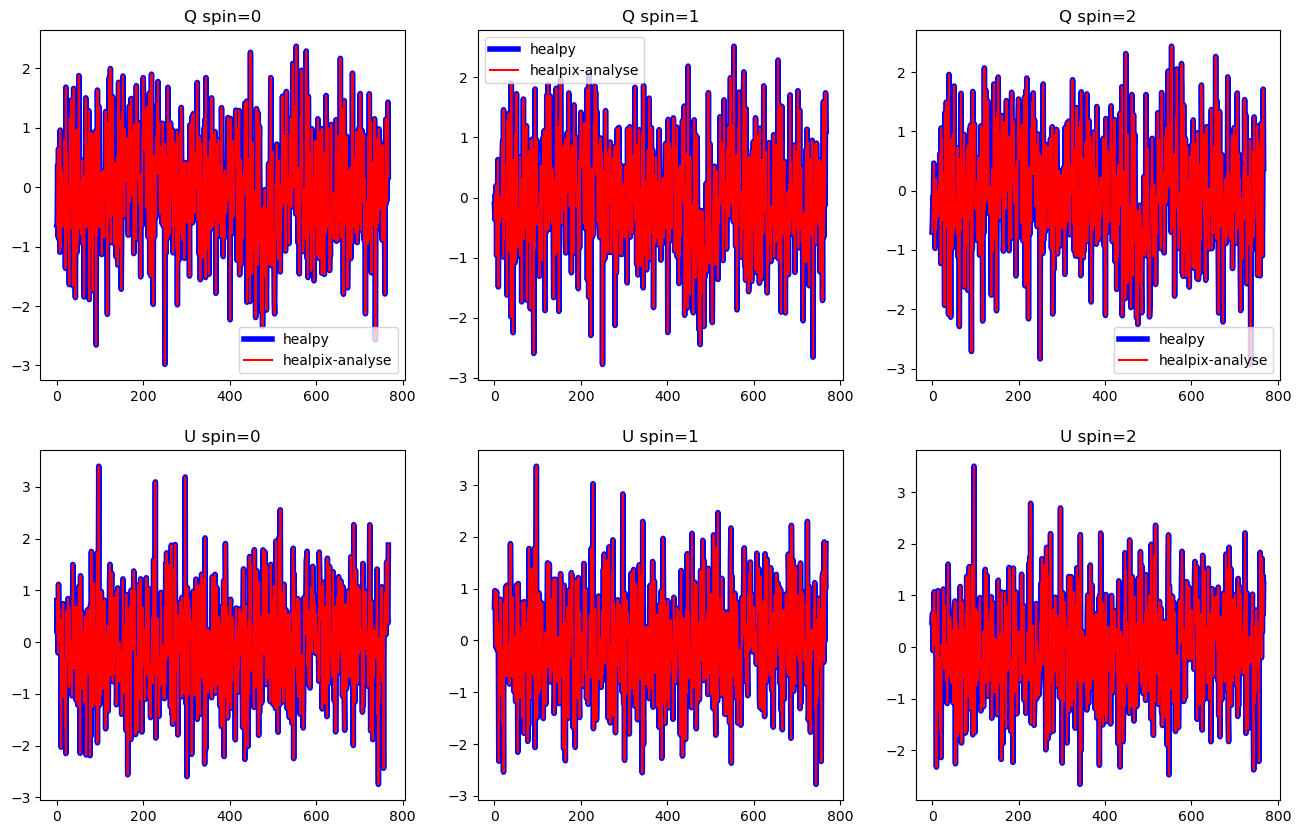

In [5]:

plt.figure(figsize=(16,10))
for spin in range(3):
    # Spin-2 (Q/U → E/B) — pour l'apprentissage
    almE, almB = sht.map2alm_spin(Q,U, spin=spin)
    almE_hp, almB_hp = hp.map2alm_spin(np.vstack([Q,U]),spin)
    
    Q_rec, U_rec = sht.alm2map_spin(almE, almB, spin=spin)
    Q_rec_hp, U_rec_hp = hp.alm2map_spin([almE_hp, almB_hp],nside, spin,3*nside-1)
    
    plt.subplot(2,3,1+spin)
    plt.title('Q spin=%d'%(spin))
    plt.plot(Q_rec_hp.real,color='b',lw=4,label='healpy')
    plt.plot(Q_rec.cpu().numpy().real,color='r',label='healpix-analyse')
    plt.legend()
    plt.subplot(2,3,4+spin)
    plt.title('U spin=%d'%(spin))
    plt.plot(U_rec_hp.real,color='b',lw=4,label='healpy')
    plt.plot(U_rec.cpu().numpy().real,color='r',label='healpix-analyse')

In [6]:
# Curl/Div d'un champ vectoriel (spin=1)
div, curl = sht.uv_to_curl_div(Q, U)

In [7]:
try:
    import cdsapi
except:
    !pip install xarray cdsapi

In [8]:
#!/usr/bin/env python
import xarray as xr

try:
    dsG = xr.open_dataset("outputGT10m.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "165.128/166.128", #u,v at 10m
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid":"N256",
    }, "outputGT10m.grib")
    dsG = xr.open_dataset("outputGT10m.grib")

dsG

<xarray.Dataset> Size: 33MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    u10         (number, values) float32 14MB ...
    v10         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-26T16:04 GRIB to CDM+CF via cfgrib-0.9.1...

# convert ERA5 data into healpix using ALM

In [9]:
from healpix_analyse.alm_latlon import build_rings_from_latlon,map2alm_latlon

ring_theta, ring_phi_list, ring_counts, idx = build_rings_from_latlon(np.deg2rad(90.0-dsG.latitude.values),
                         np.deg2rad(dsG.longitude.values))

nside_out=64 # keep small to get rapid results

almu = map2alm_latlon(torch.tensor(dsG.u10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)
almv = map2alm_latlon(torch.tensor(dsG.v10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)

In [10]:
sht = HEALPixSHT(nside=nside_out)

imu = sht.alm2map(almu)
imv = sht.alm2map(almv)

# comput div,curl from u,v field

In [11]:
div, curl = sht.uv_to_curl_div(imu, imv)

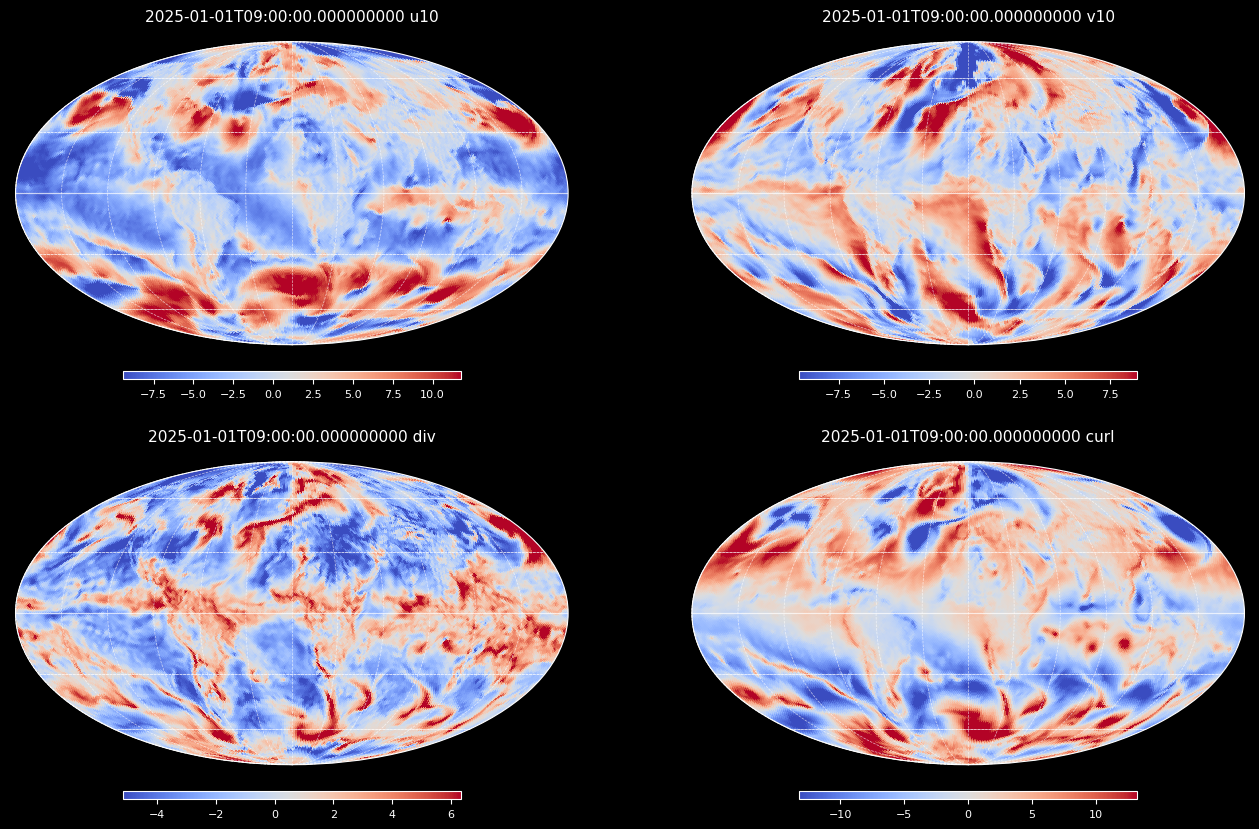

In [12]:
from healpix_plot.mollview import mollview

plt.figure(figsize=(16,10))
mollview(imu.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' u10',hold=False,sub=(2,2,1))
mollview(imv.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' v10',hold=False,sub=(2,2,2))
mollview(div.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' div',hold=False,sub=(2,2,3))
mollview(curl.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' curl',hold=False,sub=(2,2,4))